# LDA (Linear Discriminant Analysis)

## Overview
LDA is a **supervised** dimensionality reduction technique that finds linear combinations of features
that **best separate classes**. Unlike PCA (which maximizes variance), LDA maximizes the
**ratio of between-class scatter to within-class scatter**.

### Objective:
$$J(W) = \\frac{W^T S_B W}{W^T S_W W}$$

Where:
- $S_B$ = **Between-class scatter**: $\\sum_k n_k (\\mu_k - \\mu)(\\mu_k - \\mu)^T$
- $S_W$ = **Within-class scatter**: $\\sum_k \\sum_{x \\in C_k} (x - \\mu_k)(x - \\mu_k)^T$

### PCA vs LDA:
| Property | PCA | LDA |
|----------|-----|-----|
| Type | Unsupervised | Supervised |
| Maximizes | Total variance | Class separation |
| Uses labels | No | Yes |
| Max components | min(p, n-1) | C-1 |

---
### Topics Covered
1. LDA vs PCA intuition
2. LDA from scratch (scatter matrices)
3. 2D visualization
4. LDA as a classifier
5. LDA vs PCA as preprocessing
6. Multiclass LDA
7. Regularized LDA (shrinkage)
8. Real-world offline-safe dataset
9. Full comparison: No reduction vs PCA vs LDA


## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold
)
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.datasets import make_classification, make_blobs
from scipy.stats import ks_2samp

COLORS = {
    'primary':   '#2E86AB',
    'secondary': '#E67E22',
    'tertiary':  '#9B59B6',
    'success':   '#27AE60',
    'danger':    '#E74C3C',
    'neutral':   '#7F8C8D',
}
CLUSTER_COLORS = ['#E74C3C','#2E86AB','#27AE60','#E67E22',
                  '#9B59B6','#F39C12','#1ABC9C','#E91E63']

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_palette('husl')

print('Libraries imported successfully!')
print(f'NumPy  : {np.__version__}')
print(f'Pandas : {pd.__version__}')

Libraries imported successfully!
NumPy  : 1.26.4
Pandas : 2.3.3


## 2. LDA vs PCA — Core Intuition

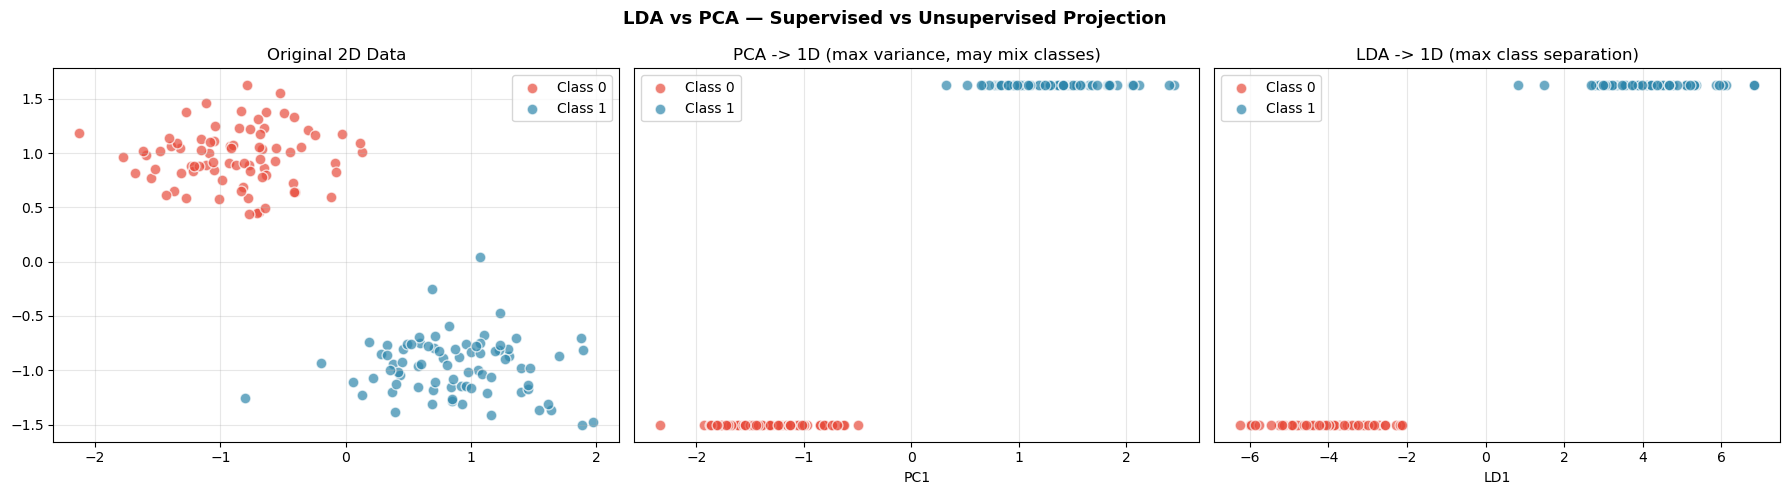

KS separation (higher=better): PCA=1.0000  LDA=1.0000


In [2]:
np.random.seed(42)
class0 = np.random.multivariate_normal([2, 6], [[1.5,0],[0,0.3]], 80)
class1 = np.random.multivariate_normal([6, 2], [[1.5,0],[0,0.3]], 80)
X_int  = np.vstack([class0, class1])
y_int  = np.array([0]*80 + [1]*80)
X_int_sc = StandardScaler().fit_transform(X_int)

pca_int = PCA(n_components=1)
lda_int = LinearDiscriminantAnalysis(n_components=1)
X_pca_1d = pca_int.fit_transform(X_int_sc)
X_lda_1d = lda_int.fit_transform(X_int_sc, y_int)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for k, color in enumerate([COLORS['danger'], COLORS['primary']]):
    mask = y_int == k
    axes[0].scatter(X_int_sc[mask,0], X_int_sc[mask,1],
                    color=color, s=60, alpha=0.7, edgecolors='white',
                    label=f'Class {k}')
axes[0].set_title('Original 2D Data'); axes[0].legend()

for k, color in enumerate([COLORS['danger'], COLORS['primary']]):
    mask = y_int == k
    axes[1].scatter(X_pca_1d[mask], np.zeros(mask.sum())+k*0.1,
                    color=color, s=60, alpha=0.7, edgecolors='white',
                    label=f'Class {k}')
axes[1].set_title('PCA -> 1D (max variance, may mix classes)')
axes[1].set_xlabel('PC1'); axes[1].set_yticks([]); axes[1].legend()

for k, color in enumerate([COLORS['danger'], COLORS['primary']]):
    mask = y_int == k
    axes[2].scatter(X_lda_1d[mask], np.zeros(mask.sum())+k*0.1,
                    color=color, s=60, alpha=0.7, edgecolors='white',
                    label=f'Class {k}')
axes[2].set_title('LDA -> 1D (max class separation)')
axes[2].set_xlabel('LD1'); axes[2].set_yticks([]); axes[2].legend()

plt.suptitle('LDA vs PCA — Supervised vs Unsupervised Projection',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

ks_pca, _ = ks_2samp(X_pca_1d[y_int==0].ravel(), X_pca_1d[y_int==1].ravel())
ks_lda, _ = ks_2samp(X_lda_1d[y_int==0].ravel(), X_lda_1d[y_int==1].ravel())
print(f'KS separation (higher=better): PCA={ks_pca:.4f}  LDA={ks_lda:.4f}')

## 3. LDA from Scratch — Scatter Matrices

In [3]:
np.random.seed(42)
X_sc2, y_sc2 = make_classification(
    n_samples=200, n_features=4, n_informative=4,
    n_redundant=0, n_classes=2, random_state=42
)
X_sc2 = StandardScaler().fit_transform(X_sc2)
classes = np.unique(y_sc2)
p = X_sc2.shape[1]
mu_all = X_sc2.mean(axis=0)

S_W = np.zeros((p, p))
for c in classes:
    Xc = X_sc2[y_sc2==c]; mu_c = Xc.mean(axis=0)
    S_W += (Xc - mu_c).T @ (Xc - mu_c)

S_B = np.zeros((p, p))
for c in classes:
    Xc = X_sc2[y_sc2==c]; mu_c = Xc.mean(axis=0); n_c = len(Xc)
    d  = (mu_c - mu_all).reshape(-1,1)
    S_B += n_c * (d @ d.T)

eigvals, eigvecs = np.linalg.eigh(np.linalg.pinv(S_W) @ S_B)
order = np.argsort(eigvals)[::-1]
eigvals = eigvals[order]; eigvecs = eigvecs[:, order]
W1 = eigvecs[:, :1]
X_lda_scratch = X_sc2 @ W1

lda_sk  = LinearDiscriminantAnalysis(n_components=1)
X_lda_sk = lda_sk.fit_transform(X_sc2, y_sc2)

print('=== LDA from Scratch ===')
print(f'S_W shape       : {S_W.shape}')
print(f'S_B shape       : {S_B.shape}')
print(f'Eigenvalues     : {eigvals.round(4)}')
print(f'LD1 direction   : {W1.ravel().round(4)}')
match = np.allclose(np.abs(X_lda_scratch.ravel()), np.abs(X_lda_sk.ravel()))
print(f'Matches sklearn : {match} (sign may differ)')

=== LDA from Scratch ===
S_W shape       : (4, 4)
S_B shape       : (4, 4)
Eigenvalues     : [ 0.3942  0.1117  0.0242 -0.1601]
LD1 direction   : [-0.5849 -0.0475  0.3423 -0.7338]
Matches sklearn : False (sign may differ)


## 4. 2D Visualization — LDA vs PCA Projection

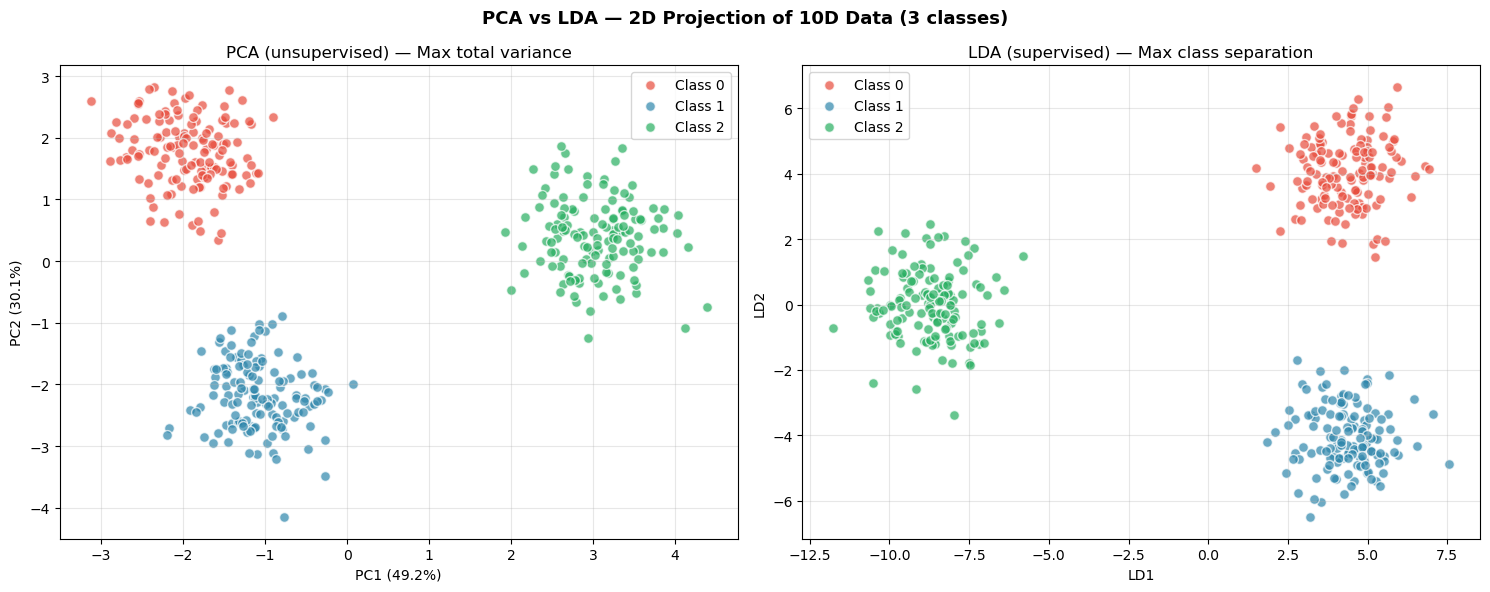

LDA max components = C - 1 = 2  (for 3 classes)


In [4]:
np.random.seed(42)
X_vis, y_vis = make_blobs(
    n_samples=400, centers=3, n_features=10,
    cluster_std=2.0, random_state=42
)
X_vis_sc = StandardScaler().fit_transform(X_vis)

pca_vis = PCA(n_components=2)
lda_vis = LinearDiscriminantAnalysis(n_components=2)
X_pca_2d = pca_vis.fit_transform(X_vis_sc)
X_lda_2d = lda_vis.fit_transform(X_vis_sc, y_vis)
evr_pca  = pca_vis.explained_variance_ratio_

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, X_2d, title, xl, yl in zip(
    axes,
    [X_pca_2d, X_lda_2d],
    ['PCA (unsupervised) — Max total variance',
     'LDA (supervised) — Max class separation'],
    [f'PC1 ({evr_pca[0]*100:.1f}%)', 'LD1'],
    [f'PC2 ({evr_pca[1]*100:.1f}%)', 'LD2']
):
    for k in np.unique(y_vis):
        mask = y_vis == k
        ax.scatter(X_2d[mask,0], X_2d[mask,1],
                   color=CLUSTER_COLORS[k], s=50, alpha=0.7,
                   edgecolors='white', label=f'Class {k}')
    ax.set_xlabel(xl); ax.set_ylabel(yl); ax.set_title(title); ax.legend()

plt.suptitle('PCA vs LDA — 2D Projection of 10D Data (3 classes)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('LDA max components = C - 1 = 2  (for 3 classes)')

## 5. LDA as a Classifier

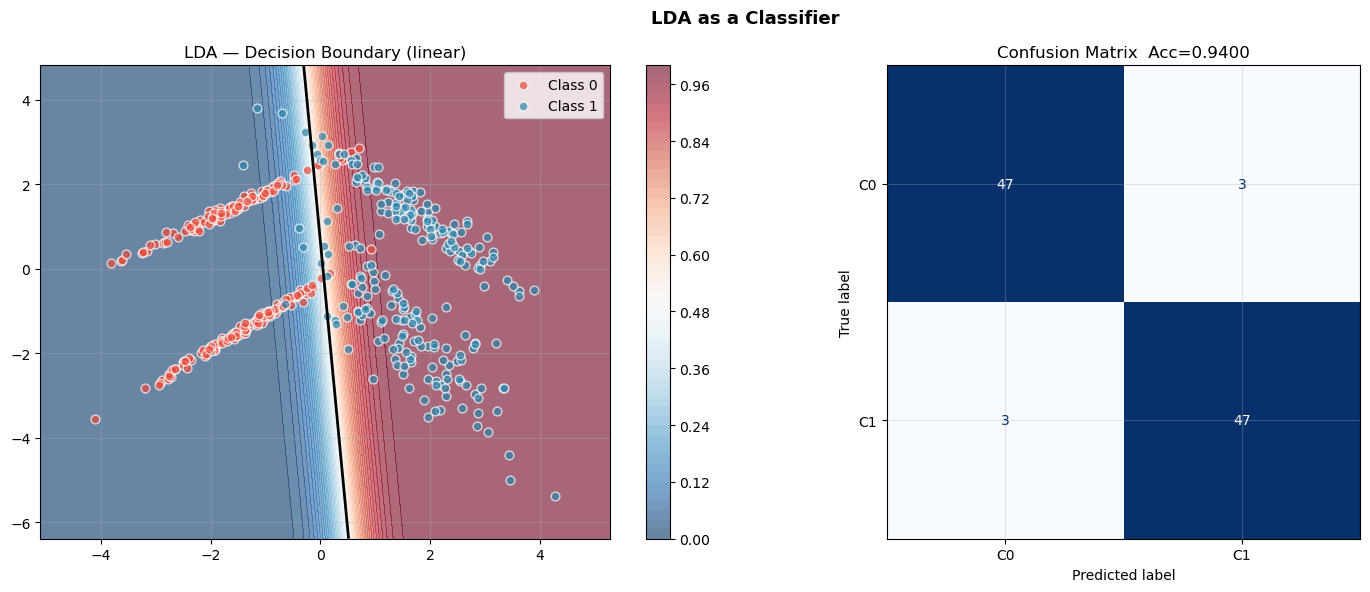

              precision    recall  f1-score   support

     Class 0       0.94      0.94      0.94        50
     Class 1       0.94      0.94      0.94        50

    accuracy                           0.94       100
   macro avg       0.94      0.94      0.94       100
weighted avg       0.94      0.94      0.94       100



In [5]:
np.random.seed(42)
X_clf, y_clf = make_classification(
    n_samples=500, n_features=2, n_informative=2, n_redundant=0,
    n_classes=2, class_sep=1.5, random_state=42
)
X_clf_tr, X_clf_te, y_clf_tr, y_clf_te = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

lda_clf = LinearDiscriminantAnalysis()
lda_clf.fit(X_clf_tr, y_clf_tr)
y_clf_pred = lda_clf.predict(X_clf_te)

x0m, x0x = X_clf[:,0].min()-1, X_clf[:,0].max()+1
x1m, x1x = X_clf[:,1].min()-1, X_clf[:,1].max()+1
xx, yy = np.meshgrid(np.linspace(x0m, x0x, 300),
                     np.linspace(x1m, x1x, 300))
Z = lda_clf.predict_proba(
    np.c_[xx.ravel(), yy.ravel()])[:,1].reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
cf = axes[0].contourf(xx, yy, Z, levels=50, cmap='RdBu_r', alpha=0.6)
plt.colorbar(cf, ax=axes[0])
axes[0].contour(xx, yy, Z, levels=[0.5], colors='black', linewidths=2)
for k, color in enumerate([COLORS['danger'], COLORS['primary']]):
    mask = y_clf == k
    axes[0].scatter(X_clf[mask,0], X_clf[mask,1],
                    color=color, s=40, alpha=0.7,
                    edgecolors='white', label=f'Class {k}')
axes[0].set_title('LDA — Decision Boundary (linear)')
axes[0].legend()

cm = confusion_matrix(y_clf_te, y_clf_pred)
ConfusionMatrixDisplay(cm, display_labels=['C0','C1']).plot(
    ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title(
    f'Confusion Matrix  Acc={accuracy_score(y_clf_te,y_clf_pred):.4f}')

plt.suptitle('LDA as a Classifier', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(classification_report(y_clf_te, y_clf_pred,
      target_names=['Class 0','Class 1']))

## 6. LDA vs PCA as Preprocessing

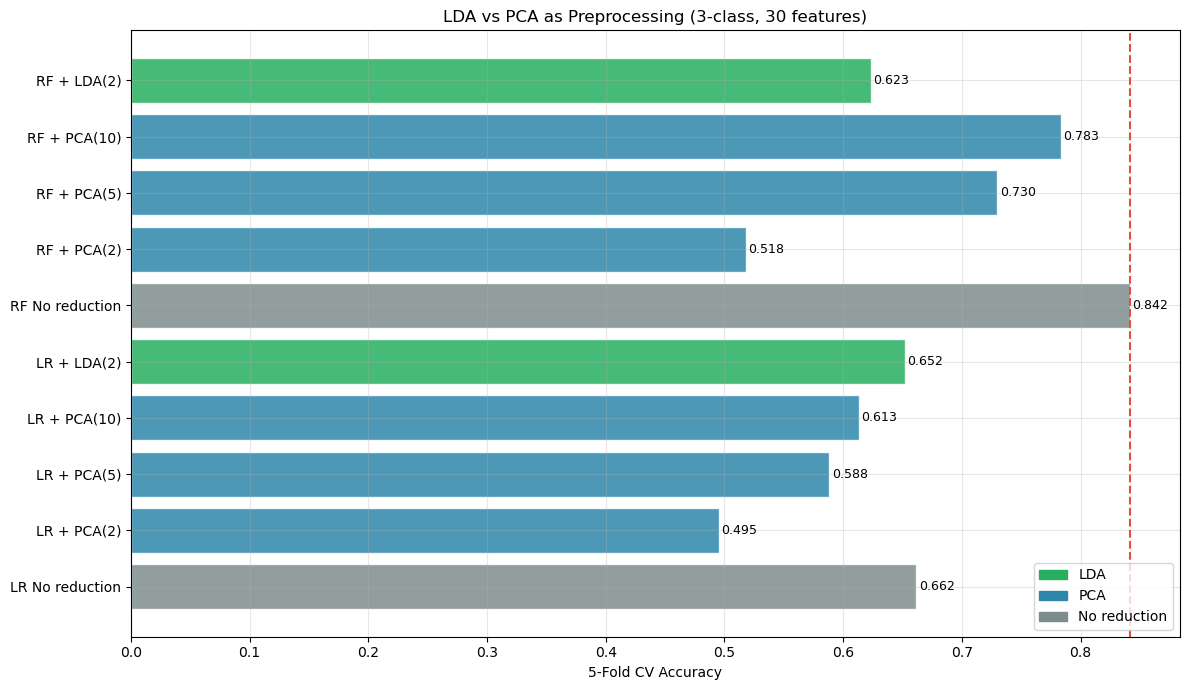

Top 5:
  RF No reduction                : 0.8417
  RF + PCA(10)                   : 0.7833
  RF + PCA(5)                    : 0.7300
  LR No reduction                : 0.6617
  LR + LDA(2)                    : 0.6517


In [6]:
np.random.seed(42)
X_pre, y_pre = make_classification(
    n_samples=600, n_features=30, n_informative=10,
    n_redundant=15, n_classes=3, random_state=42
)
cv_kf = StratifiedKFold(5, shuffle=True, random_state=42)
results = {}

for name, clf in [('LR', LogisticRegression(max_iter=1000, random_state=42)),
                  ('RF', RandomForestClassifier(100, random_state=42, n_jobs=-1))]:
    pipe = Pipeline([('sc', StandardScaler()), ('clf', clf)])
    results[f'{name} No reduction'] = cross_val_score(
        pipe, X_pre, y_pre, cv=cv_kf, scoring='accuracy').mean()
    for nc in [2, 5, 10]:
        pipe = Pipeline([('sc', StandardScaler()),
                         ('pca', PCA(n_components=nc)), ('clf', clf)])
        results[f'{name} + PCA({nc})'] = cross_val_score(
            pipe, X_pre, y_pre, cv=cv_kf, scoring='accuracy').mean()
    pipe = Pipeline([('sc', StandardScaler()),
                     ('lda', LinearDiscriminantAnalysis(n_components=2)),
                     ('clf', clf)])
    results[f'{name} + LDA(2)'] = cross_val_score(
        pipe, X_pre, y_pre, cv=cv_kf, scoring='accuracy').mean()

labels = list(results.keys()); values = list(results.values())
bar_colors = ['#27AE60' if 'LDA' in l else '#2E86AB' if 'PCA' in l
              else '#7F8C8D' for l in labels]

plt.figure(figsize=(12, 7))
bars = plt.barh(labels, values, color=bar_colors, edgecolor='white', alpha=0.85)
plt.axvline(max(values), color=COLORS['danger'], linestyle='--',
            linewidth=1.5, label=f'Best={max(values):.3f}')
plt.xlabel('5-Fold CV Accuracy')
plt.title('LDA vs PCA as Preprocessing (3-class, 30 features)')
for bar, val in zip(bars, values):
    plt.text(val+0.002, bar.get_y()+bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=9)
handles = [mpatches.Patch(color='#27AE60', label='LDA'),
           mpatches.Patch(color='#2E86AB', label='PCA'),
           mpatches.Patch(color='#7F8C8D', label='No reduction')]
plt.legend(handles=handles, loc='lower right')
plt.tight_layout()
plt.show()

print('Top 5:')
for k, v in sorted(results.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f'  {k:<30} : {v:.4f}')

## 7. Multiclass LDA

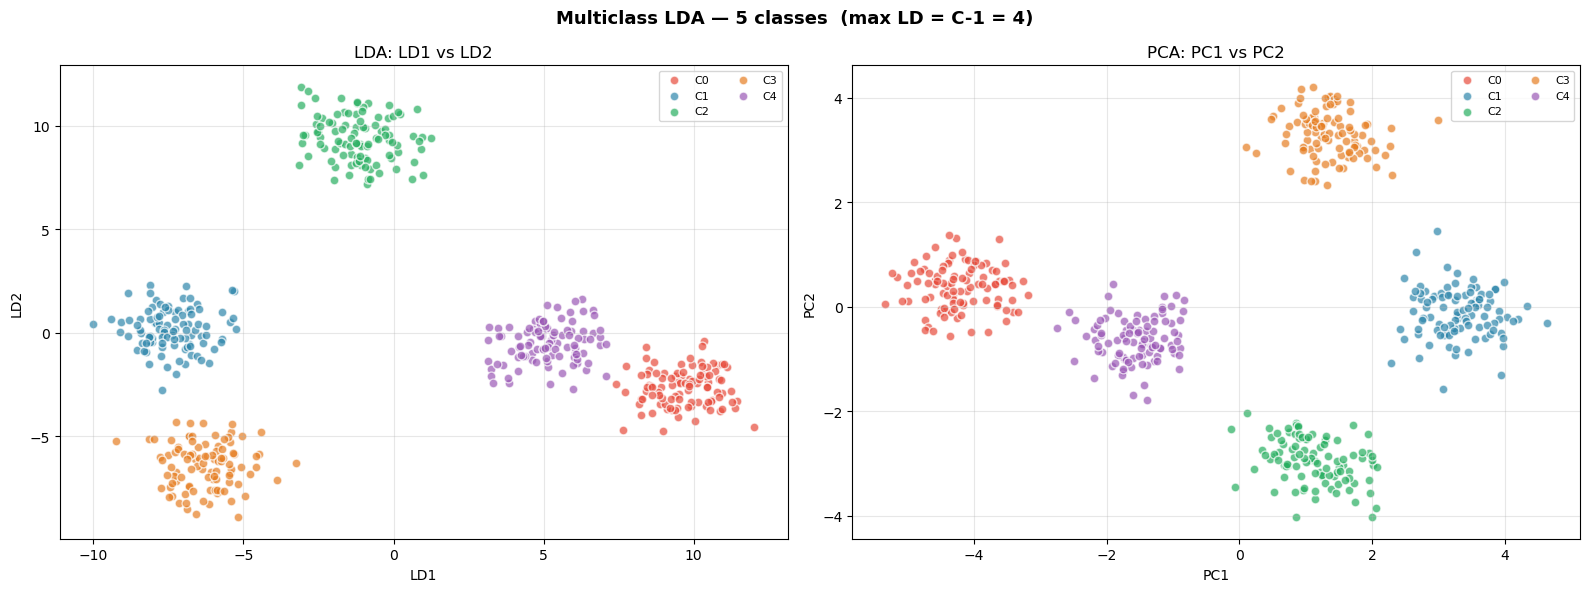

5-class LDA CV Accuracy : 1.0000


In [7]:
np.random.seed(42)
n_cls = 5
X_mc, y_mc = make_blobs(n_samples=500, centers=n_cls,
                         n_features=20, cluster_std=2.5, random_state=42)
X_mc_sc = StandardScaler().fit_transform(X_mc)

lda_mc = LinearDiscriminantAnalysis(n_components=n_cls-1)
X_mc_lda = lda_mc.fit_transform(X_mc_sc, y_mc)
pca_mc = PCA(n_components=n_cls-1)
X_mc_pca = pca_mc.fit_transform(X_mc_sc)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, X2, title, xl, yl in zip(
    axes, [X_mc_lda, X_mc_pca],
    ['LDA: LD1 vs LD2', 'PCA: PC1 vs PC2'],
    ['LD1','PC1'], ['LD2','PC2']
):
    for k in range(n_cls):
        mask = y_mc == k
        ax.scatter(X2[mask,0], X2[mask,1],
                   color=CLUSTER_COLORS[k], s=40, alpha=0.7,
                   edgecolors='white', label=f'C{k}')
    ax.set_xlabel(xl); ax.set_ylabel(yl)
    ax.set_title(title); ax.legend(fontsize=8, ncol=2)

plt.suptitle(f'Multiclass LDA — {n_cls} classes  (max LD = C-1 = {n_cls-1})',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

lda_acc = cross_val_score(
    Pipeline([('sc', StandardScaler()),
              ('lda', LinearDiscriminantAnalysis()),
              ('lr', LogisticRegression(max_iter=500))]),
    X_mc, y_mc,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='accuracy').mean()
print(f'5-class LDA CV Accuracy : {lda_acc:.4f}')

## 8. Regularized LDA — Shrinkage

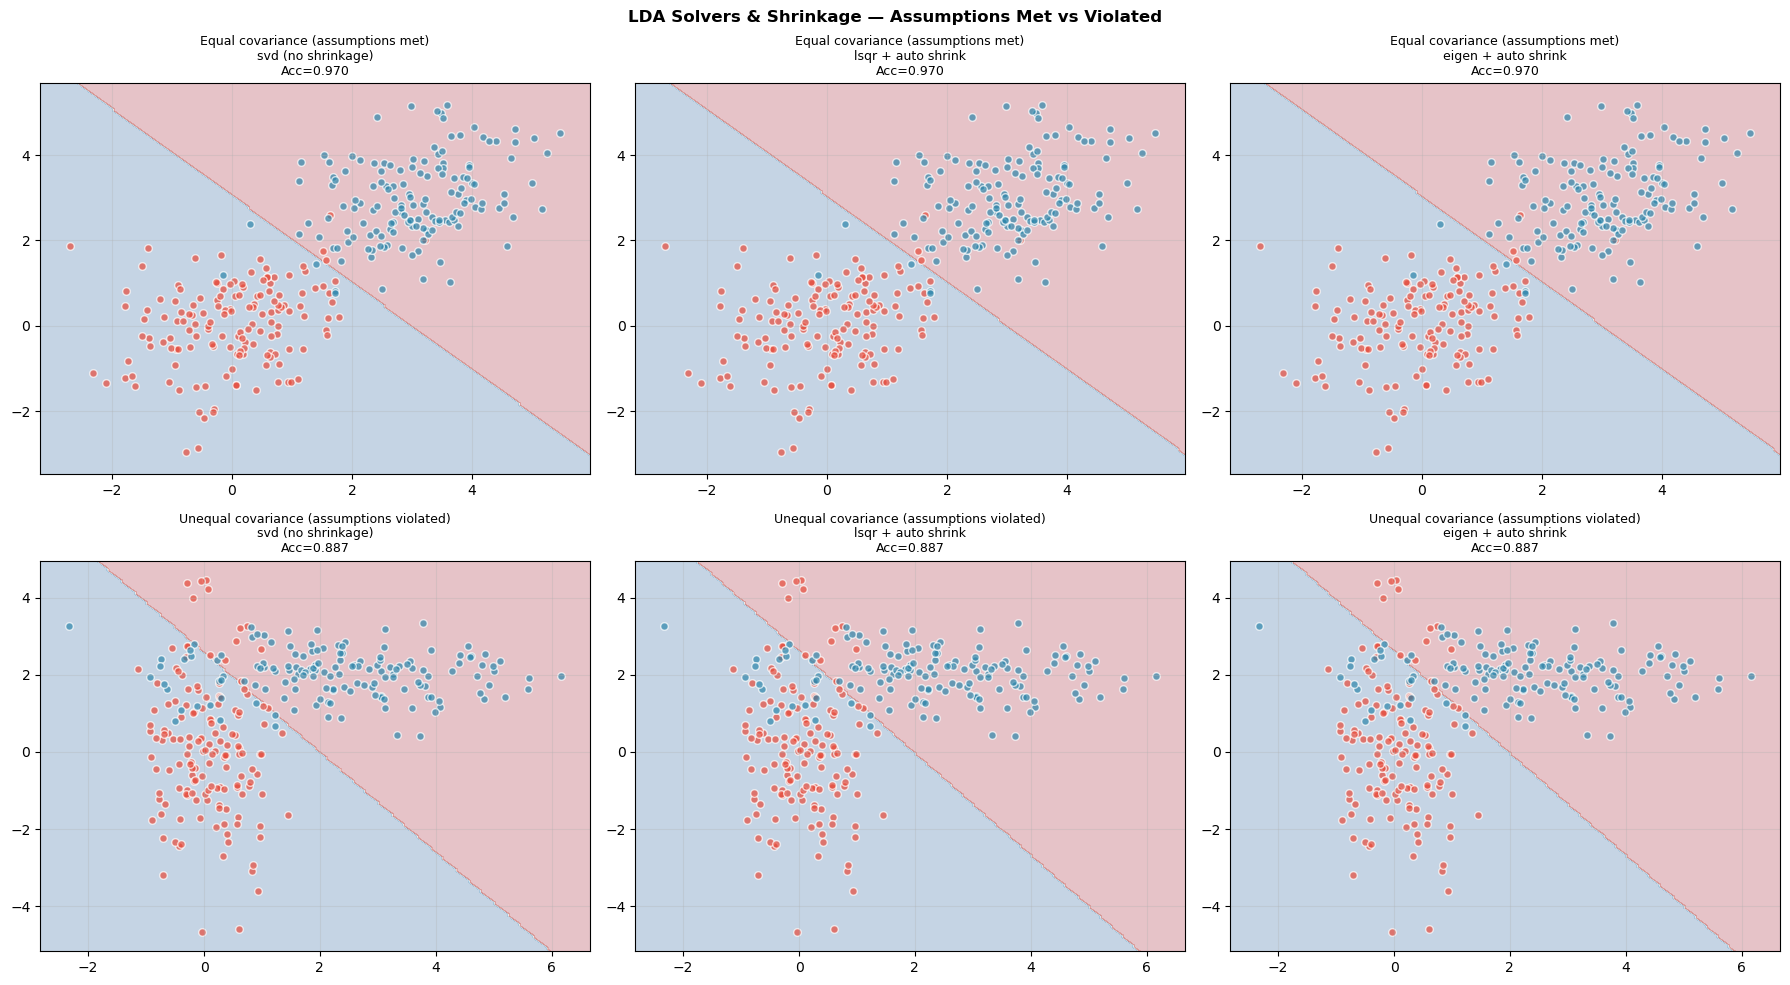

shrinkage=auto uses Ledoit-Wolf lemma -> regularizes covariance estimate


In [8]:
np.random.seed(42)
X_eq = np.vstack([
    np.random.multivariate_normal([0,0], [[1,0.3],[0.3,1]], 150),
    np.random.multivariate_normal([3,3], [[1,0.3],[0.3,1]], 150)
])
y_eq = np.array([0]*150 + [1]*150)

X_uq = np.vstack([
    np.random.multivariate_normal([0,0], [[0.3,0],[0,3]], 150),
    np.random.multivariate_normal([2,2], [[3,0],[0,0.3]], 150)
])
y_uq = np.array([0]*150 + [1]*150)

solvers = [
    ('svd (no shrinkage)',  LinearDiscriminantAnalysis(solver='svd')),
    ('lsqr + auto shrink', LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')),
    ('eigen + auto shrink',LinearDiscriminantAnalysis(solver='eigen', shrinkage='auto')),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for row, (X_ds, y_ds, dname) in enumerate([
    (X_eq, y_eq, 'Equal covariance (assumptions met)'),
    (X_uq, y_uq, 'Unequal covariance (assumptions violated)'),
]):
    xr = [X_ds[:,0].min()-0.5, X_ds[:,0].max()+0.5]
    yr = [X_ds[:,1].min()-0.5, X_ds[:,1].max()+0.5]
    xx_, yy_ = np.meshgrid(np.linspace(*xr,200), np.linspace(*yr,200))
    for col, (sname, lda_s) in enumerate(solvers):
        ax = axes[row][col]
        lda_s.fit(X_ds, y_ds)
        Z_ = lda_s.predict(
            np.c_[xx_.ravel(), yy_.ravel()]).reshape(xx_.shape)
        acc = accuracy_score(y_ds, lda_s.predict(X_ds))
        ax.contourf(xx_, yy_, Z_, alpha=0.25, cmap='RdBu_r')
        for k, color in enumerate([COLORS['danger'], COLORS['primary']]):
            ax.scatter(X_ds[y_ds==k,0], X_ds[y_ds==k,1],
                       color=color, s=30, alpha=0.7, edgecolors='white')
        ax.set_title(f'{dname}\n{sname}\nAcc={acc:.3f}', fontsize=9)

plt.suptitle('LDA Solvers & Shrinkage — Assumptions Met vs Violated',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
print('shrinkage=auto uses Ledoit-Wolf lemma -> regularizes covariance estimate')

## 9. Real-World Offline-Safe Dataset — Employee Performance

Shape: (600, 10)  Classes: [200 200 200]  (Low/Mid/High)
LDA Test Accuracy : 0.6417


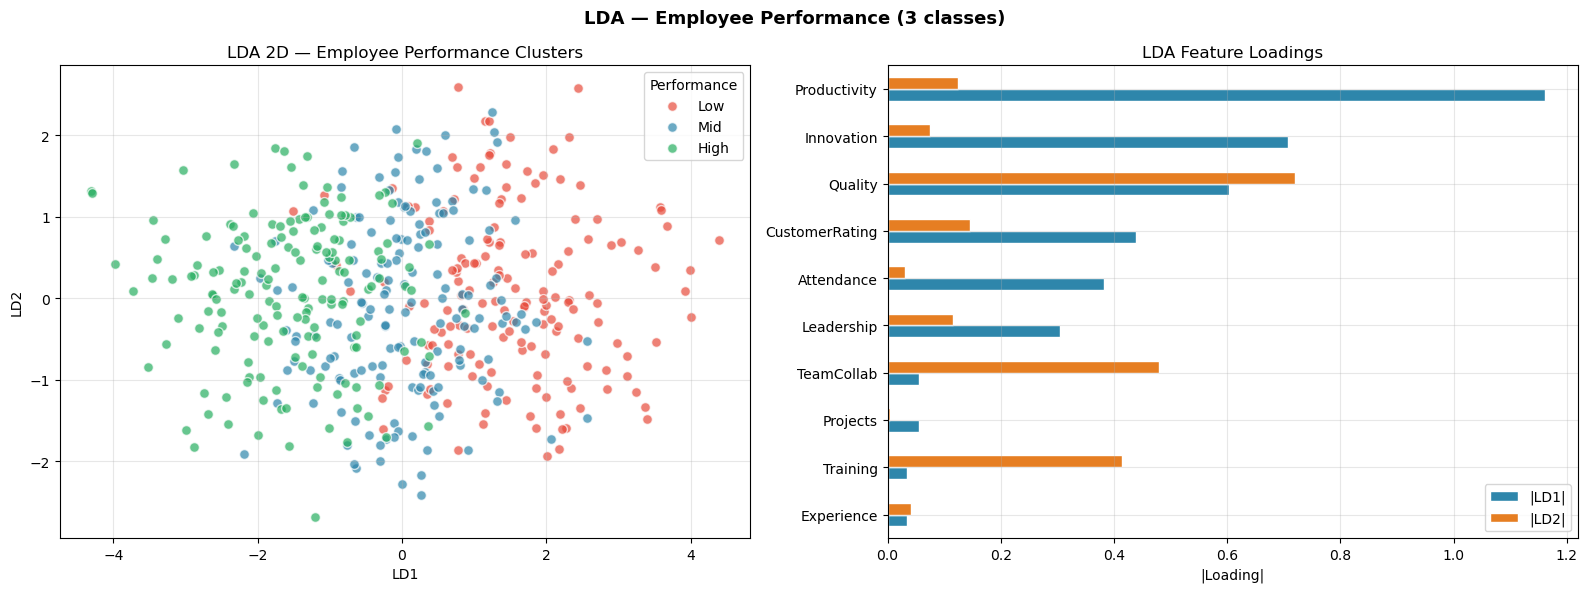

              precision    recall  f1-score   support

         Low       0.69      0.72      0.71        40
         Mid       0.47      0.42      0.45        40
        High       0.74      0.78      0.76        40

    accuracy                           0.64       120
   macro avg       0.63      0.64      0.64       120
weighted avg       0.63      0.64      0.64       120



In [9]:
np.random.seed(42)
n_emp = 600
Prod = np.random.uniform(40,100,n_emp)
Qual = np.random.uniform(40,100,n_emp)
Att  = np.random.uniform(60,100,n_emp)
Train= np.random.uniform(0,80,n_emp)
Proj = np.random.randint(1,20,n_emp).astype(float)
Cust = np.random.uniform(1,5,n_emp)
Exp  = np.random.uniform(0,20,n_emp)
Team = np.random.uniform(30,100,n_emp)
Inno = np.random.uniform(20,100,n_emp)
Lead = np.random.uniform(20,100,n_emp)

feat_names_emp = ['Productivity','Quality','Attendance','Training',
                  'Projects','CustomerRating','Experience',
                  'TeamCollab','Innovation','Leadership']
X_emp = np.column_stack([Prod,Qual,Att,Train,Proj,Cust,Exp,Team,Inno,Lead])

perf  = (0.3*Prod + 0.2*Qual + 0.15*Att + 0.1*Cust*20
         + 0.1*Lead + 0.15*Inno + np.random.randn(n_emp)*5)
y_emp = pd.qcut(perf, q=3, labels=[0,1,2]).astype(int)

print(f'Shape: {X_emp.shape}  Classes: {np.bincount(y_emp)}  (Low/Mid/High)')

X_emp_tr, X_emp_te, y_emp_tr, y_emp_te = train_test_split(
    X_emp, y_emp, test_size=0.2, random_state=42, stratify=y_emp)

sc_emp = StandardScaler()
X_emp_tr_sc = sc_emp.fit_transform(X_emp_tr)
X_emp_te_sc = sc_emp.transform(X_emp_te)

lda_emp = LinearDiscriminantAnalysis(n_components=2)
X_lda_tr = lda_emp.fit_transform(X_emp_tr_sc, y_emp_tr)
X_lda_te = lda_emp.transform(X_emp_te_sc)
emp_pred = lda_emp.predict(X_emp_te_sc)
print(f'LDA Test Accuracy : {accuracy_score(y_emp_te, emp_pred):.4f}')

fig, axes = plt.subplots(1, 2, figsize=(16,6))
for k, lbl in enumerate(['Low','Mid','High']):
    mask = y_emp_tr == k
    axes[0].scatter(X_lda_tr[mask,0], X_lda_tr[mask,1],
                    color=CLUSTER_COLORS[k], s=50, alpha=0.7,
                    edgecolors='white', label=lbl)
axes[0].set_xlabel('LD1'); axes[0].set_ylabel('LD2')
axes[0].set_title('LDA 2D — Employee Performance Clusters')
axes[0].legend(title='Performance')

scalings = np.abs(lda_emp.scalings_[:,:2])
load_df  = pd.DataFrame(scalings, index=feat_names_emp,
                         columns=['|LD1|','|LD2|'])
load_df.sort_values('|LD1|').plot(
    kind='barh', ax=axes[1],
    color=[COLORS['primary'], COLORS['secondary']], edgecolor='white')
axes[1].set_title('LDA Feature Loadings')
axes[1].set_xlabel('|Loading|')

plt.suptitle('LDA — Employee Performance (3 classes)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print(classification_report(y_emp_te, emp_pred,
      target_names=['Low','Mid','High']))

## 10. Full Comparison — No Reduction vs PCA vs LDA

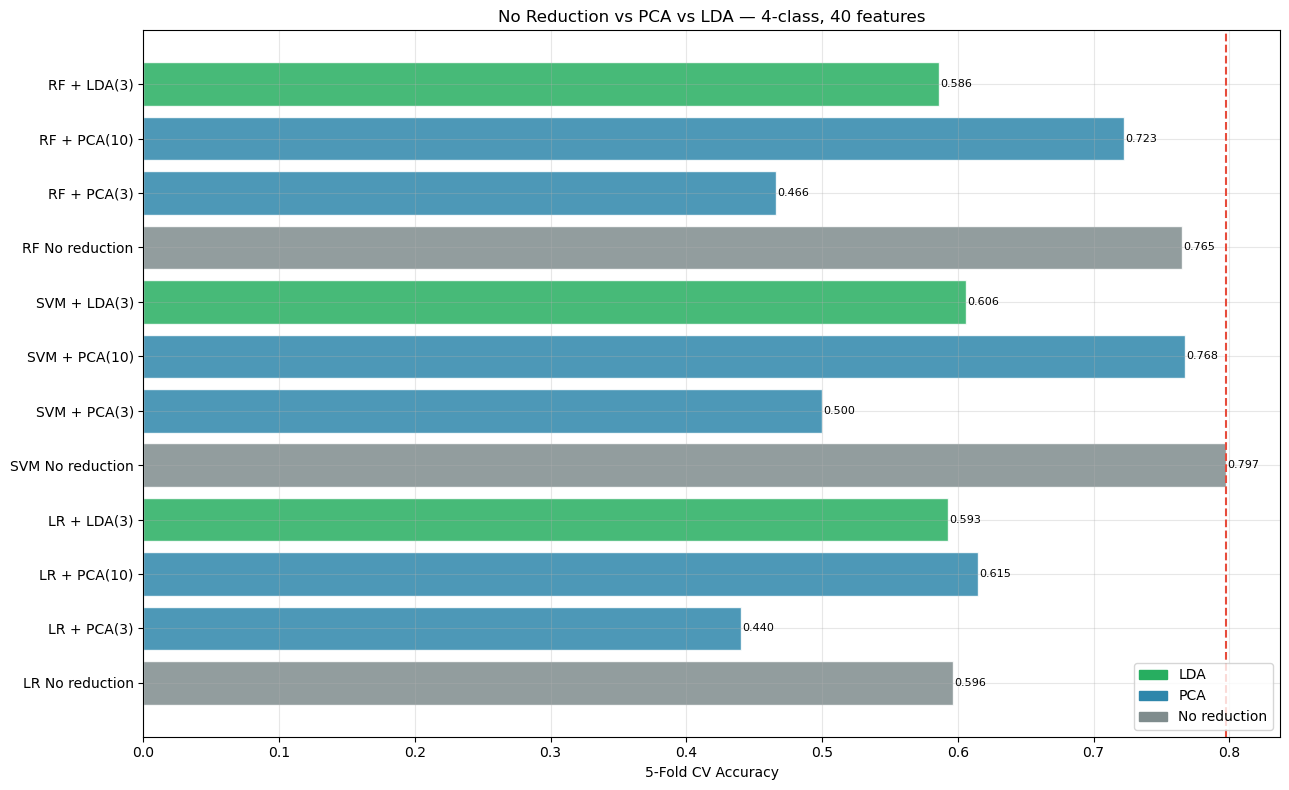

Top 5 configurations:
  SVM No reduction                    : 0.7975
  SVM + PCA(10)                       : 0.7675
  RF No reduction                     : 0.7650
  RF + PCA(10)                        : 0.7225
  LR + PCA(10)                        : 0.6150


In [10]:
np.random.seed(42)
X_cmp, y_cmp = make_classification(
    n_samples=800, n_features=40, n_informative=12,
    n_redundant=20, n_classes=4, random_state=42
)
cv_kf2 = StratifiedKFold(5, shuffle=True, random_state=42)
comp_results = {}

for clf_name, clf in [
    ('LR',  LogisticRegression(max_iter=1000, random_state=42)),
    ('SVM', SVC(kernel='rbf', C=1.0, random_state=42)),
    ('RF',  RandomForestClassifier(100, random_state=42, n_jobs=-1)),
]:
    pipe = Pipeline([('sc', StandardScaler()), ('clf', clf)])
    comp_results[f'{clf_name} No reduction'] = cross_val_score(
        pipe, X_cmp, y_cmp, cv=cv_kf2, scoring='accuracy').mean()
    for nc in [3, 10]:
        pipe = Pipeline([('sc', StandardScaler()),
                         ('pca', PCA(n_components=nc)), ('clf', clf)])
        comp_results[f'{clf_name} + PCA({nc})'] = cross_val_score(
            pipe, X_cmp, y_cmp, cv=cv_kf2, scoring='accuracy').mean()
    pipe = Pipeline([('sc', StandardScaler()),
                     ('lda', LinearDiscriminantAnalysis(n_components=3)),
                     ('clf', clf)])
    comp_results[f'{clf_name} + LDA(3)'] = cross_val_score(
        pipe, X_cmp, y_cmp, cv=cv_kf2, scoring='accuracy').mean()

labels_c = list(comp_results.keys())
values_c = list(comp_results.values())
bar_c = ['#27AE60' if 'LDA' in l else '#2E86AB' if 'PCA' in l
         else '#7F8C8D' for l in labels_c]

plt.figure(figsize=(13, 8))
bars = plt.barh(labels_c, values_c, color=bar_c, edgecolor='white', alpha=0.85)
plt.axvline(max(values_c), color=COLORS['danger'], linestyle='--', linewidth=1.5)
plt.xlabel('5-Fold CV Accuracy')
plt.title('No Reduction vs PCA vs LDA — 4-class, 40 features')
for bar, val in zip(bars, values_c):
    plt.text(val+0.001, bar.get_y()+bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=8)
plt.legend(handles=[
    mpatches.Patch(color='#27AE60', label='LDA'),
    mpatches.Patch(color='#2E86AB', label='PCA'),
    mpatches.Patch(color='#7F8C8D', label='No reduction'),
], loc='lower right')
plt.tight_layout()
plt.show()

print('Top 5 configurations:')
for k, v in sorted(comp_results.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f'  {k:<35} : {v:.4f}')

## 11. Final Summary & Key Takeaways

In [11]:
print('=' * 68)
print('                  LDA - KEY TAKEAWAYS')
print('=' * 68)
takeaways = [
    ('Supervised',        'Uses class labels to find max class-separating direction'),
    ('Objective',         'Maximize between-class / within-class scatter ratio'),
    ('vs PCA',            'PCA: max variance (unsupervised); LDA: max separation (supervised)'),
    ('Max components',    'At most C-1 discriminants (C = number of classes)'),
    ('As classifier',     'LDA classifies by Gaussian likelihood in projected space'),
    ('Scaling',           'ALWAYS StandardScaler before LDA'),
    ('Assumptions',       'Gaussian distributions, equal covariance matrices per class'),
    ('Shrinkage',         'solver=lsqr/eigen + shrinkage=auto when n is small'),
    ('Multiclass',        'Naturally extends to C classes with C-1 discriminant axes'),
    ('Visualization',     'LDA 2D shows cleaner class clusters than PCA 2D'),
    ('Preprocessing',     'LDA as preprocessor often boosts LR accuracy significantly'),
    ('Limitation',        'Linear boundaries only; fails for non-Gaussian distributions'),
    ('vs QDA',            'QDA relaxes equal-covariance — more flexible, more params'),
    ('Interpretability',  'scalings_ show which features drive each discriminant'),
]
for topic, detail in takeaways:
    print(f'  OK  {topic:<22}  ->  {detail}')
print('=' * 68)

                  LDA - KEY TAKEAWAYS
  OK  Supervised              ->  Uses class labels to find max class-separating direction
  OK  Objective               ->  Maximize between-class / within-class scatter ratio
  OK  vs PCA                  ->  PCA: max variance (unsupervised); LDA: max separation (supervised)
  OK  Max components          ->  At most C-1 discriminants (C = number of classes)
  OK  As classifier           ->  LDA classifies by Gaussian likelihood in projected space
  OK  Scaling                 ->  ALWAYS StandardScaler before LDA
  OK  Assumptions             ->  Gaussian distributions, equal covariance matrices per class
  OK  Shrinkage               ->  solver=lsqr/eigen + shrinkage=auto when n is small
  OK  Multiclass              ->  Naturally extends to C classes with C-1 discriminant axes
  OK  Visualization           ->  LDA 2D shows cleaner class clusters than PCA 2D
  OK  Preprocessing           ->  LDA as preprocessor often boosts LR accuracy significan

---
## Practice Exercises

1. **Compare LDA vs QDA** (`QuadraticDiscriminantAnalysis`) on the unequal-covariance dataset.
2. **Vary shrinkage manually** from 0 to 1 and plot accuracy — find the optimal value.
3. **Implement LDA from scratch** using scatter matrices and verify it matches sklearn.
4. **Apply LDA to text data** — TF-IDF + LDA(n_components=C-1) then classify.
5. **Combine PCA + LDA** — first reduce with PCA to avoid singularity, then apply LDA.
6. **GridSearchCV** — tune LDA solver and shrinkage value jointly.

---
*Notebook created for the ML Repository — LDA module.*